# 1/Import the data set you exported in Exercise 4.9 into a new Jupyter notebook. This should be the merged version of your data that contains the new customers column.

In [38]:
# creating libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [39]:
# creating path
path = r'C:\Users\bouas\instacart bascket analysis'
intro_to_data_410 = pd.read_pickle(os.path.join(path, 'data', 'prepared_data', 'intro_to_data_410.pkl'))

In [40]:
df = intro_to_data_410

In [41]:
df.columns

Index(['user_id', 'gender', 'STATE', 'age', 'date_joined',
       'household_dependents', 'familiar_status', 'income', 'Unnamed: 0',
       'product_id', 'product_name', 'aisle_id', 'department_id', 'prices',
       'order_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order', 'add_to_cart_order',
       'reordered', 'price_range_loc', 'Busiest day', 'Busiest days',
       'busiest_period_of_day', 'max_order', 'loyalty_flag', 'mean_price',
       'spending_flag', 'median_days_since_last_orders',
       'order_frequency_flag', '_merge'],
      dtype='object')

# key question 5 : What’s the distribution among users in regards to their brand loyalty?

##### we ve already did this chart, but i want to make more clear

In [42]:
df['loyalty_flag'].value_counts()

loyalty_flag
Regular customer    15877395
Loyal customer      10284396
New customer         6244250
Name: count, dtype: int64

In [43]:
loyalty_counts = df['loyalty_flag'].value_counts()

(array([0, 1, 2]),
 [Text(0, 0, 'Regular customer'),
  Text(1, 0, 'Loyal customer'),
  Text(2, 0, 'New customer')])

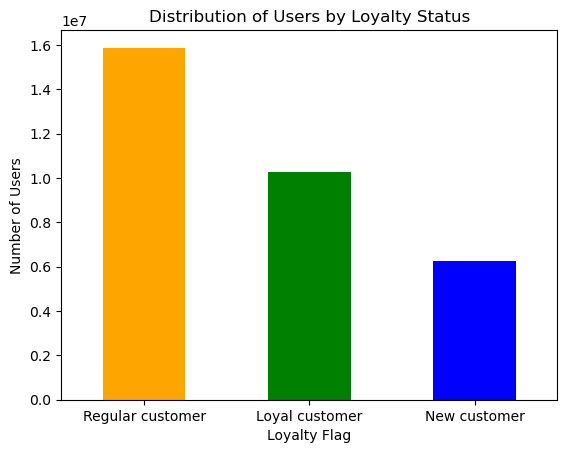

In [44]:

loyalty_counts = loyalty_counts.plot(kind='bar', color=['orange', 'green', 'blue']) 
plt.title('Distribution of Users by Loyalty Status')
plt.xlabel('Loyalty Flag') 
plt.ylabel('Number of Users')
plt.xticks(rotation=0)


In [45]:
loyalty_counts.figure.savefig(os.path.join(path, 'data', 'prepared_data', 'loyalty_counts.png'))

# 2/Consider any security implications that might exist for this new data. You’ll need to address any PII data in the data before continuing your analysis

### >>> The names of the people have already been dropped

# 3/The Instacart officers are interested in comparing customer behavior in different geographic areas. Create a regional segmentation of the data. You’ll need to create a “Region” column based on the “State” column from your customers data set.

### Creation of region column

In [46]:
# checking state number
df['STATE'].nunique()


51

##### checking state name

In [47]:
df['STATE'].value_counts()

STATE
Pennsylvania            667094
California              659828
Rhode Island            656935
Georgia                 656414
New Mexico              654499
Arizona                 654005
North Carolina          651928
Oklahoma                651760
Alaska                  648519
Minnesota               647851
Massachusetts           646378
Wyoming                 644283
Virginia                641432
Missouri                640761
Texas                   640432
Colorado                639293
Maine                   638593
North Dakota            638507
Alabama                 638041
Kansas                  637570
Louisiana               637506
Delaware                637049
South Carolina          636768
Oregon                  636442
Nevada                  636163
Arkansas                636158
New York                636003
Montana                 635280
South Dakota            633786
Illinois                633059
Hawaii                  632922
Washington              632877
Mi

In [48]:
# Definition of official US regions, source :  (U.S. Census Bureau)
northeast = [ 'Maine','New Hampshire','Vermont','Massachusetts','Rhode Island','Connecticut',
    'New York','Pennsylvania','New Jersey']
midwest = [ 'Wisconsin','Michigan','Illinois','Indiana','Ohio',
    'North Dakota','South Dakota','Nebraska','Kansas','Minnesota','Iowa','Missouri']
south = ['Delaware','Maryland','District of Columbia','Virginia','West Virginia', 'North Carolina',
         'South Carolina','Georgia','Florida',
    'Kentucky','Tennessee','Mississippi','Alabama',
    'Oklahoma','Texas','Arkansas','Louisiana']
west = ['Idaho','Montana','Wyoming','Nevada','Utah','Colorado','Arizona','New Mexico',
    'Alaska','Washington','Oregon','California','Hawaii']





In [49]:
def assign_region(state):  
    if state in northeast:
        return 'Northeast'
    elif state in midwest:
        return 'Midwest'
    elif state in south:
        return 'South'
    elif state in west:
        return 'West'
    else:
        return 'Other'


df['REGION'] = df['STATE'].apply(assign_region)  

In [50]:
# Check 1

df[['STATE', 'REGION']].head()

,STATE,REGION
0,Missouri,Midwest
1,Missouri,Midwest
2,Missouri,Midwest
3,Missouri,Midwest
4,Missouri,Midwest


In [51]:
# Check 2
df['REGION'].value_counts()

REGION
South        10792300
West          8293217
Midwest       7597585
Northeast     5722939
Name: count, dtype: int64

In [52]:
df['spending_flag'].dtype


dtype('O')

##### I wanted to use `group by` to cross the two variables, but it lagged for tens of minutes because `sependers flag` was `object`. That's why I changed it and used `crosstab`.

In [53]:

regional_spending = pd.crosstab(df['REGION'], df['spending_flag'], dropna = False)


Text(0.5, 1.0, 'Regional Spending')

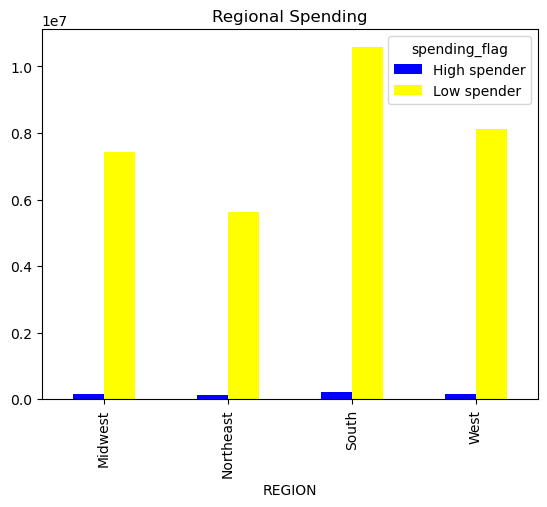

In [54]:
# establishing bar chart
regional_spending = regional_spending.plot(kind='bar',color = ['blue', 'yellow'])
plt.title ('Regional Spending')



In [55]:
regional_spending.figure.savefig(os.path.join(path, 'data', 'prepared_data', 'regional_spending.png'))

# 4/The Instacart CFO isn’t interested in customers who don’t generate much revenue for the app. Create an exclusion flag for low-activity customers (customers with less than 5 orders) and exclude them from the data. Make sure you export this sample.

##### creating 

In [56]:
df.loc[df['max_order'] < 5, 'customer_activity'] = 'not_active'
df.loc[df['max_order'] >= 5, 'customer_activity'] = 'active'

In [57]:
# checking new colomn
df['customer_activity'].value_counts(dropna = False)

customer_activity
active        30965686
not_active     1440355
Name: count, dtype: int64

In [58]:
# creating new df for low customers activity
df_not_active_customers= df[df['customer_activity']=='not_active']

In [59]:
# exportinf df for low activity customers
df_not_active_customers.to_pickle(os.path.join(path, 'data', 'prepared_data', 'low_activity_customers.pkl'))

In [60]:
# exclunding low costomers activity and keeping the active
df1 = df[df['customer_activity']== 'active']


In [61]:
df1.shape

(30965686, 35)

##### cheking resultts

In [62]:
df1.head()

,user_id,gender,STATE,age,date_joined,household_dependents,familiar_status,income,Unnamed: 0,product_id,...,busiest_period_of_day,max_order,loyalty_flag,mean_price,spending_flag,median_days_since_last_orders,order_frequency_flag,_merge,REGION,customer_activity
0,26711,Female,Missouri,48,1/1/2017,3,married,165665,195,196,...,Most orders,8,New customer,7.988889,Low spender,19.0,Regular customer,both,Midwest,active
1,26711,Female,Missouri,48,1/1/2017,3,married,165665,195,196,...,Most orders,8,New customer,7.988889,Low spender,19.0,Regular customer,both,Midwest,active
2,26711,Female,Missouri,48,1/1/2017,3,married,165665,195,196,...,Most orders,8,New customer,7.988889,Low spender,19.0,Regular customer,both,Midwest,active
3,26711,Female,Missouri,48,1/1/2017,3,married,165665,6184,6184,...,Most orders,8,New customer,7.988889,Low spender,19.0,Regular customer,both,Midwest,active
4,26711,Female,Missouri,48,1/1/2017,3,married,165665,6184,6184,...,Most orders,8,New customer,7.988889,Low spender,19.0,Regular customer,both,Midwest,active


In [63]:
df1.to_pickle(os.path.join(path, 'data', 'prepared_data', 'active_customers.pkl'))

# 5/The marketing and business strategy units at Instacart want to create more-relevant marketing strategies for different products and are, thus, curious about customer profiling in their database

### key questions 3  Instacart has a lot of products with different price tags. Marketing and sales want to use simpler price range groupings to help direct their efforts

In [64]:
df1['price_range_loc'].value_counts()

price_range_loc
Low-range product     9674881
Mid-range product      622964
High-range product     397953
Name: count, dtype: int64

# [Note: Please take into consideration that in 4-7 and when creating this column, I used a sample of 10 million to save PC memory. That's why I obtained these results on only 10 million. If I set `drop nana false`, they will appear in the context.]

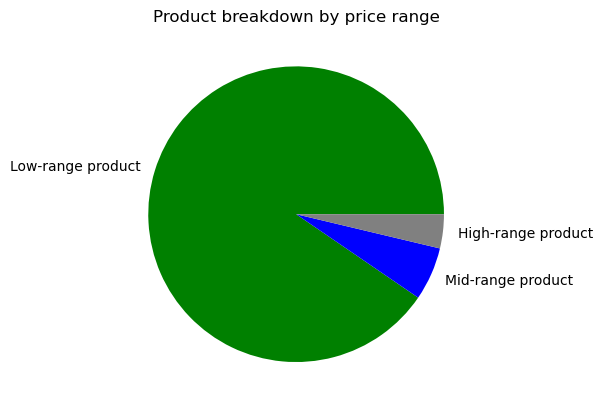

In [65]:
Product_breakdown_by_price_range = df1['price_range_loc'].value_counts().plot(kind='pie', colors=['green', 'blue', 'gray'])

plt.title('Product breakdown by price range')
plt.ylabel('')
plt.show()


In [66]:
Product_breakdown_by_price_range.figure.savefig(os.path.join(path, 'data', 'prepared_data', 'Product_breakdown_by_price_range.png'))

### Key Questions 4 : Are there certain types of products that are more popular than others? The marketing and sales teams want to know which departments have the highest frequency of product orders.

In [67]:
df1['department_id'].value_counts()

department_id
4     9079273
16    5177182
19    2766406
7     2571901
1     2121731
13    1782705
3     1120828
15    1012074
20    1003834
9      822136
17     699857
12     674781
14     671872
11     424359
18     410392
6      255991
5      144674
8       93060
21      64768
2       34411
10      33451
Name: count, dtype: int64

In [68]:
# setting the department name from our data dictionary
dept_names = {
    1: 'Frozen',
    2: 'Other',
    3: 'Bakery',
    4: 'Produce',
    5: 'Alcohol',
    6: 'International',
    7: 'Beverages',
    8: 'Pets',
    9: 'Dry Goods Pasta',
    10: 'Bulk',
    11: 'Personal Care',
    12: 'Meat Seafood',
    13: 'Pantry',
    14: 'Breakfast',
    15: 'Canned Goods',
    16: 'Dairy Eggs',
    17: 'Household',
    18: 'Babies',
    19: 'Snacks',
    20: 'Deli',
    21: 'Missing'
}


In [69]:
df1['department_name'] = df1['department_id'].map(dept_names)


C:\Users\bouas\AppData\Local\Temp\ipykernel_34592\739217820.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['department_name'] = df1['department_id'].map(dept_names)


Text(0.5, 1.0, 'department Popularity')

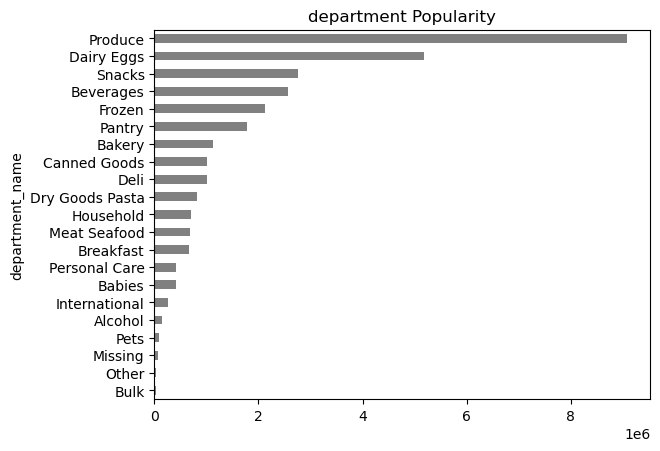

In [70]:
department_populatrity = df1['department_name'].value_counts().sort_values().plot(
    kind='barh',
    color='gray')
plt.title('department Popularity')


### The most frequently ordered departments are Produce, Dairy & Eggs, and Snacks, indicating that customers primarily purchase fresh, fast-food items. Departments such as Pets, Alcohol, babies and International are significantly less popular.

###### exporting chart

In [71]:

department_populatrity.figure.savefig(os.path.join(path, 'data', 'prepared_data', 'department_populatrity.png'))

### Are there certain types of products that are more popular than others? 
#### I took the top 3 best-selling products from the top 2 departments and the least-selling products from the bottom 2 departments.

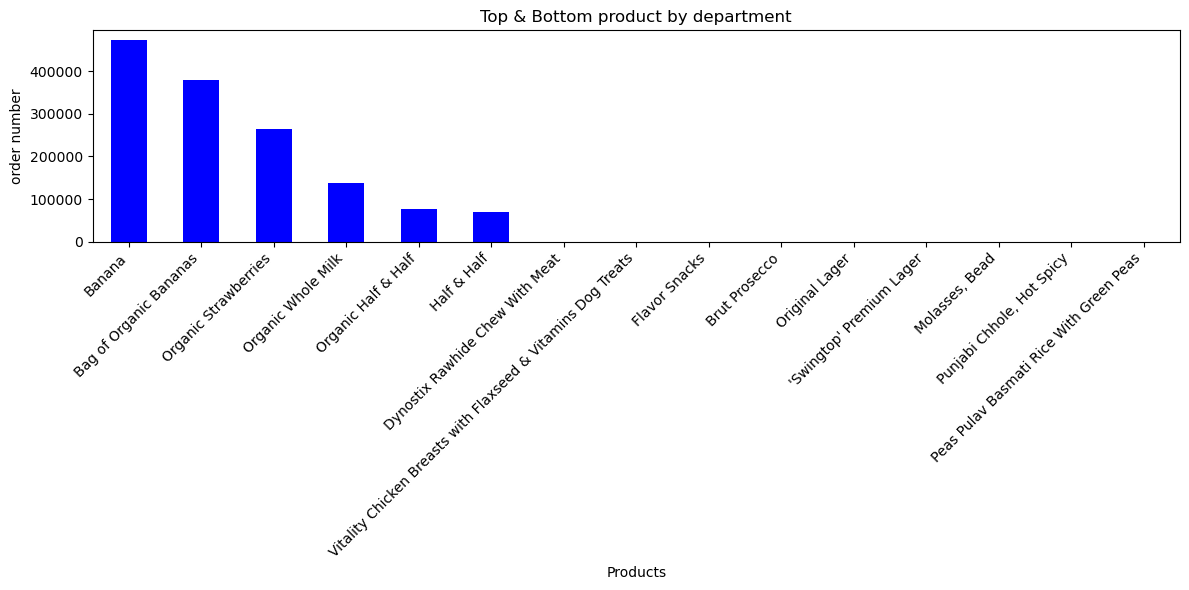

In [72]:

#  Top 3 products from top 2 departments ( to show diversity)
top_produce = df[df['department_id'] == 4]['product_name'].value_counts().head(3)
top_dairy = df[df['department_id'] == 16]['product_name'].value_counts().head(3)

# Bottom 3 
bottom_pets = df[df['department_id'] == 8]['product_name'].value_counts().tail(3)
bottom_alcohol = df[df['department_id'] == 5]['product_name'].value_counts().tail(3)
bottom_international = df[df['department_id'] == 6]['product_name'].value_counts().tail(3)

# Combine everything 
combined = pd.concat([
    top_produce.rename("Produce"),
    top_dairy.rename("Dairy Eggs"),
    bottom_pets.rename("Pets"),
    bottom_alcohol.rename("Alcohol"),
    bottom_international.rename("International")
])

# settig chart
Most_least_ordered_products_by_department = combined.plot(kind='bar', figsize=(12,6), color='blue')

plt.title('Top & Bottom product by department')
plt.xlabel('Products')
plt.ylabel('order number')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



### The most ordered products are fresh fruit and organic milk, confirming a strong preference for healthy and essential items. Conversely, international products, alcoholic beverages, and pet supplies are in very low deman

In [73]:
Most_least_ordered_products_by_department.figure.savefig(os.path.join(path, 'data', 'prepared_data', 'Most_least_ordered_products_by_department.png'))

## Creating customers profile

### Creation of customer profiles based on age group, income, and dependencies

In [74]:
df1.loc[df1['age'] < 30, 'age_group'] = 'Young adult'
df1.loc[(df1['age'] >= 30) & (df1['age'] < 50), 'age_group'] = 'Adult'
df1.loc[df1['age'] >= 50, 'age_group'] = 'Senior'

# Young parent
df1.loc[(df1['age'] < 30) & (df1['household_dependents'] > 0), 'age_group'] = 'Young parent'


C:\Users\bouas\AppData\Local\Temp\ipykernel_34592\1442957402.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.loc[df1['age'] < 30, 'age_group'] = 'Young adult'


In [75]:
df1.loc[df1['income'] < 40000, 'income_group'] = 'Low income'
df1.loc[(df1['income'] >= 40000) & (df1['income'] < 80000), 'income_group'] = 'Middle income'
df1.loc[df1['income'] >= 80000, 'income_group'] = 'High income'


C:\Users\bouas\AppData\Local\Temp\ipykernel_34592\928879712.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.loc[df1['income'] < 40000, 'income_group'] = 'Low income'


In [76]:
df1.loc[df1['household_dependents'] == 0, 'family_status'] = 'No kids'
df1.loc[df1['household_dependents'] > 0, 'family_status'] = 'With kids'


C:\Users\bouas\AppData\Local\Temp\ipykernel_34592\2333129721.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.loc[df1['household_dependents'] == 0, 'family_status'] = 'No kids'


In [77]:
df1['customer_profile'] = (
    df1['age_group'] + ' - ' +
    df1['income_group'] + ' - ' +
    df1['family_status']
)



C:\Users\bouas\AppData\Local\Temp\ipykernel_34592\2211723012.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['customer_profile'] = (


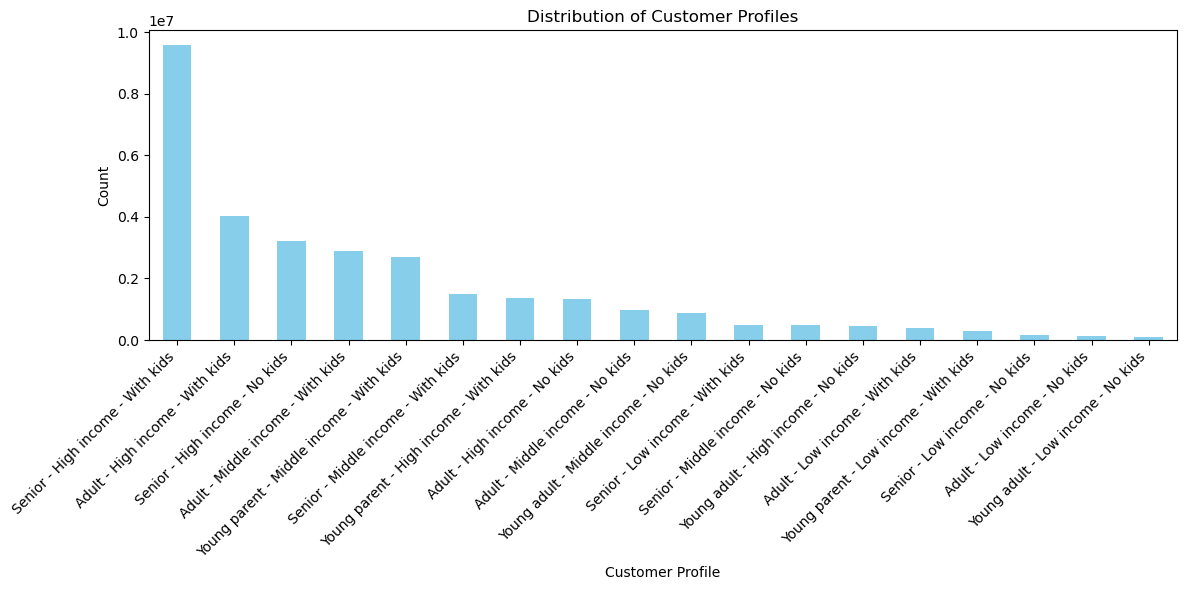

In [78]:


distribution_of_customer_profile = plt.figure(figsize=(12,6))
df1['customer_profile'].value_counts().plot(kind='bar', color='skyblue')

plt.title('Distribution of Customer Profiles')
plt.xlabel('Customer Profile')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [79]:
distribution_of_customer_profile.figure.savefig(os.path.join(path, 'data', 'prepared_data', 'distribution_of_customer_profile.png'))

### The most frequent profiles are “Senior - High Income - With Kids” and “Adult - High Income - With Kids,” suggesting that affluent families make up a dominant share of Instacart customers.
###  the profiles “Young adult - Low Income - No Kids” and “Adult - Low Income - No Kids” are significantly less common, indicating low penetration of the service among young, single people with modest incomes.

# 7a/Aggregate the max, mean, and min variables on a customer-profile level for usage frequency 

In [80]:
order_number_stats = df1.groupby('customer_profile')['order_number'].agg(
    max_order='max',
    mean_order='mean',
    min_order='min'
).round(2)



In [81]:
order_number_stats

,max_order,mean_order,min_order
customer_profile,,,
Adult - High income - No kids,99,17.67,1
Adult - High income - With kids,99,17.96,1
Adult - Low income - No kids,99,16.49,1
Adult - Low income - With kids,99,16.51,1
Adult - Middle income - No kids,99,18.24,1
Adult - Middle income - With kids,99,18.04,1
Senior - High income - No kids,99,18.20,1
Senior - High income - With kids,99,17.79,1
Senior - Low income - No kids,99,18.35,1


# 7/b aggregate the max, mean, and min variables on a customer-profile level for usage frequency and expenditure

In [82]:
price_stats = df1.groupby('customer_profile')['prices'].agg(
    max_price='max',
    mean_price='mean',
    min_price='min'
).round(2)


In [83]:
price_stats

,max_price,mean_price,min_price
customer_profile,,,
Adult - High income - No kids,25.0,7.96,1.0
Adult - High income - With kids,25.0,7.95,1.0
Adult - Low income - No kids,25.0,6.49,1.0
Adult - Low income - With kids,25.0,6.49,1.0
Adult - Middle income - No kids,25.0,7.75,1.0
Adult - Middle income - With kids,25.0,7.75,1.0
Senior - High income - No kids,25.0,7.95,1.0
Senior - High income - With kids,25.0,7.96,1.0
Senior - Low income - No kids,25.0,6.51,1.0


# 8/ Compare your customer profiles with regions and departments. Can you identify a link between them? Customers may demonstrate different behaviors across regions, which could make this information important.

## creating profile costomer/region

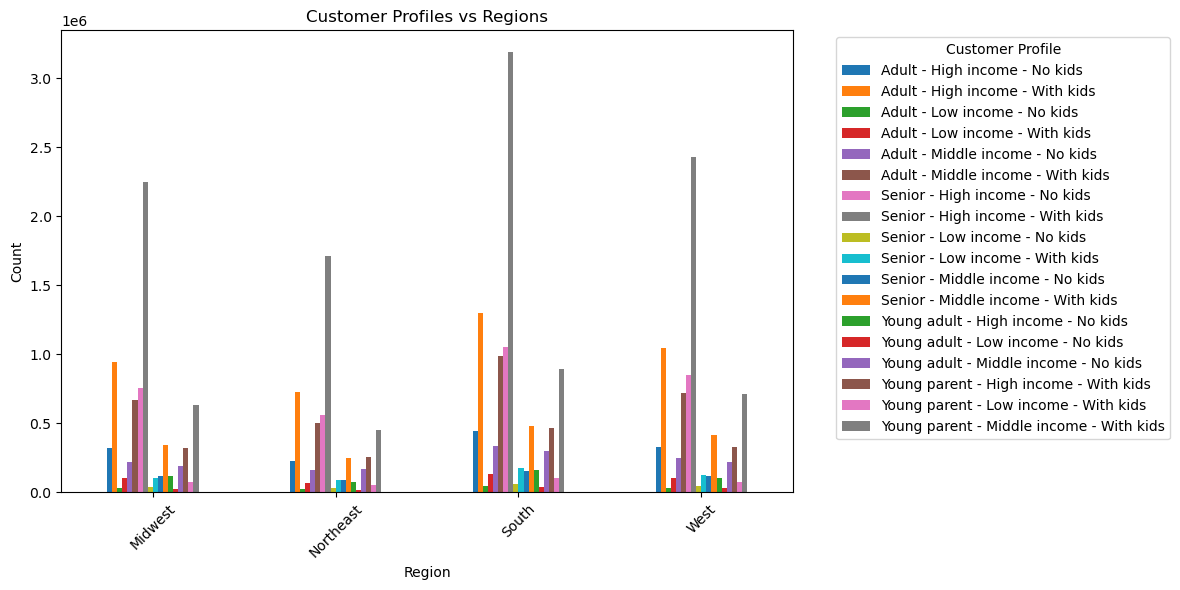

In [85]:
profile_region = pd.crosstab(df1['customer_profile'], df1['REGION'])

profile_region= profile_region.T.plot(kind='bar', figsize=(12,6))

plt.title('Customer Profiles vs Regions')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Customer Profile', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



### analysing : The "Senior - High income - With children" profile is overrepresented in the South, indicating a high population concentration. The other regions show a more balanced distribution between profiles, with less overall intensity.

In [86]:
profile_region .figure.savefig(os.path.join(path, 'data', 'prepared_data', 'profile_region.png'))

## customers profile/department

In [87]:
profile_department = pd.crosstab(df1['customer_profile'], df1['department_name'])


##### establishing heatmap

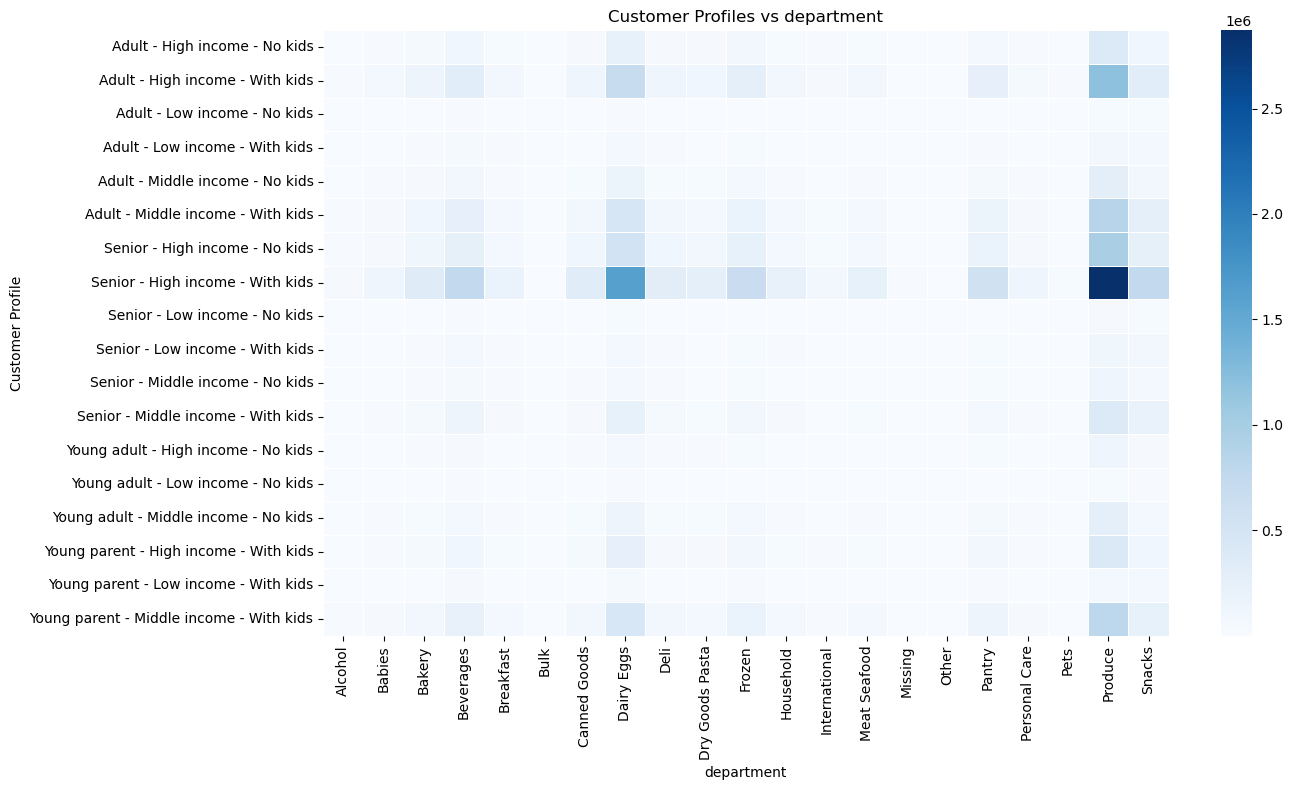

In [88]:
profile_region = df1.groupby(['customer_profile', 'department_name']).size().unstack().fillna(0)

plt.figure(figsize=(14,8))
heatmap_profile_department = sns.heatmap(profile_department, cmap='Blues', linewidths=.5)

plt.title('Customer Profiles vs department')
plt.xlabel('department')
plt.ylabel('Customer Profile')
plt.tight_layout()
plt.show()


### The “High Income – With Kids” profiles concentrate a large portion of their purchases in the produce, dairy, eggs, and snacks departments, reflecting more complete baskets geared towards family needs. Conversely, the “Low Income – With Kids” profiles show a smaller and more dispersed presence, with a relative preference for essential departments such as pantry, beverages, or frozen foods, indicating more targeted and less voluminous purchasing behaviors.

### Can you identify a link between them?

### Across regions, the most represented customer profiles (notably High Income – With Kids) appear consistently dominant, showing that affluent family households form a strong core of Instacart’s user base regardless of geography. However, when comparing profiles with departments, these same groups show a clear preference for essential and high‑volume categories such as produce, dairy eggs, and snacks, while lower‑income or no‑kids profiles display more selective purchasing patterns focused on basic or lower‑cost departments.

In [89]:
heatmap_profile_department.figure.savefig(os.path.join(path, 'data', 'prepared_data', 'heatmap_profile_department.png'))